# Imports

In [214]:
from ModifiedNEAT.nn.base import NeatModule
from ModifiedNEAT.util.storage import STORAGE_DIR
from ModifiedNEAT.util.qol import manage_params
from ModifiedNEAT.util.datetime import clock, eta
from ModifiedNEAT.util.storage import save, load
from ModifiedNEAT.util.fancy_text import CM, Fore

import ModifiedNEAT as meat
import ModifiedNEAT.nn as mnn
import ModifiedNEAT.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import warnings

from torch import Tensor
from torch.optim import Optimizer
from torch.nn.utils import clip_grad_norm_
from numpy import ndarray as CPUArray
from typing import Union
from copy import deepcopy
from matplotlib.pyplot import Axes
from numba.core.errors import NumbaPerformanceWarning

In [215]:
DEVICE = torch.device('gpu' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32
GENOMES = 100

In [216]:
warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

# Load Data

In [217]:
def create_data(genomes_num: int, records: int, features: int, classes: int, device='cpu', dtype=torch.float32):
    inp = torch.randn((records, features, classes))
    if features == 1:
        out = torch.argmax(inp, dim=-1)[..., 0]
    else:
        out = torch.randint(0, classes, size=(records,))
    return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape).contiguous(), \
           out.to(device, torch.long).unsqueeze(0).expand(genomes_num, *out.shape).contiguous()

In [218]:
CLASSES         = 10
INP_FEATURES    = 1
TRAIN_RECORDS   = 100
EVAL_RECORDS    = 80
train_inp, train_out = create_data(GENOMES, TRAIN_RECORDS, INP_FEATURES, CLASSES, dtype=DTYPE)
(eval_inp, eval_out) = create_data(GENOMES, EVAL_RECORDS, INP_FEATURES, CLASSES, dtype=DTYPE)
train_inp.shape, train_out.shape, eval_inp.shape, eval_out.shape

(torch.Size([100, 100, 1, 10]),
 torch.Size([100, 100]),
 torch.Size([100, 80, 1, 10]),
 torch.Size([100, 80]))

In [219]:
def tensor_memory(tensor: Tensor):
    """
    :param tensor: PyTorch tensor
    :return: Memory in Megabytes
    """
    return tensor.numel() * tensor.element_size() / (1024 ** 2)

In [220]:
tensor_memory(train_inp), tensor_memory(eval_inp)

(0.3814697265625, 0.30517578125)

In [221]:
train_inp.device, train_inp.dtype, train_inp.device, train_out.dtype

(device(type='cpu'), torch.float32, device(type='cpu'), torch.int64)

In [222]:
torch.max(train_inp)

tensor(3.4991)

# View data

In [223]:
def show_image(image: Tensor, title: str = None, size: tuple[int, int] = None, cmap='binary', axis: Axes = None):
    features, columns = image.shape[-2:]
    image = torch.stack([image for _ in range(columns)], dim=-2)
    print(image.shape)
    # if image.ndim == 2:
    #     image = image.unsqueeze(-3)
    if size is None:
        size = (360, 360)
    if image.ndim == 3:
        image = image.permute(1, 2, 0)
    elif image == 2:
        pass
    else:
        raise ValueError(f"Unsupported ndim")
    image = image.cpu()
    if axis is None:
        _, axis = plt.subplots(1, 1, figsize=(size[0] * 0.01, size[1] * 0.01))
    axis.imshow(image, cmap=cmap)
    if title is not None:
        axis.set_title(title)
    axis.set_axis_off()
    if axis is None:
        plt.show()

torch.Size([1, 10, 10])


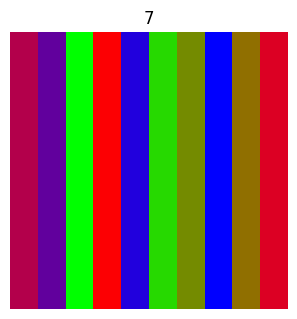

In [224]:
rand_train_idx = np.random.randint(0, TRAIN_RECORDS)
show_image(train_inp[0, rand_train_idx], train_out[0, rand_train_idx].item(), cmap='brg_r')

In [225]:
def show_batch(images: Tensor, predictions: Tensor = None, labels: Tensor = None, columns=8,
               size: tuple[int, int] = None, cmap='binary', no_axes=True):
    features_, columns_ = images.shape[-2:]
    images = torch.stack([images for _ in range(columns_)], dim=-2)
    # if images.ndim == 3:
    #     images = images.unsqueeze(-3)
    if size is None:
        size = (720, 1080)
    if images.ndim == 4:
        images = images.permute(0, 2, 3, 1)
    elif images == 3:
        pass
    else:
        raise ValueError(f"Unsupported ndim")

    images = images.cpu()
    rows = math.ceil(len(images) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(size[1] * 0.01, size[0] * 0.01))
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for index, (axis, image) in enumerate(zip(axes, images)):
        axis.imshow(image, cmap=cmap)
        title = ''
        if predictions is not None:
            title += f"P={predictions[index].cpu().item()}"
        if labels is not None:
            title += f"L={labels[index].cpu().item()}"
        if len(title) > 0:
            axis.set_title(title)
        if no_axes:
            axis.set_axis_off()
    plt.show()

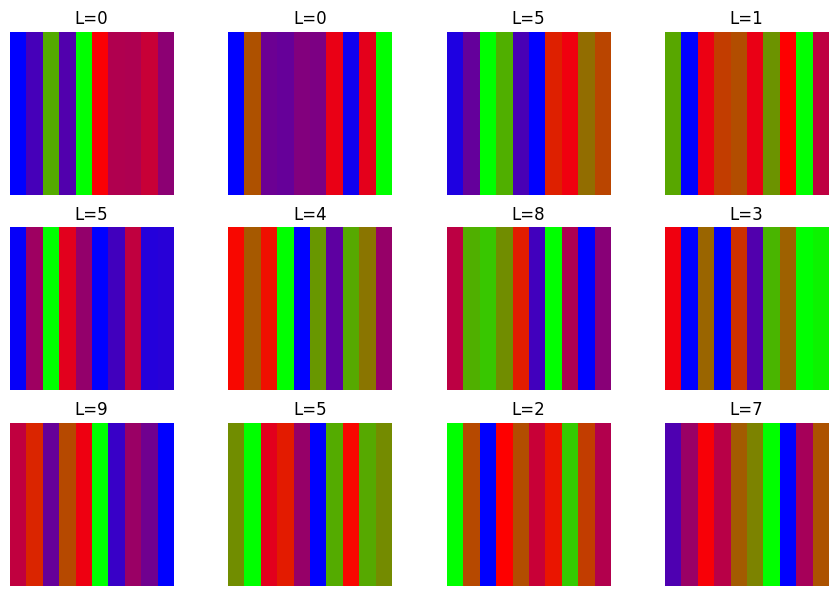

In [226]:
show_batch(train_inp[0, :12], labels=train_out[0, :12], cmap='brg_r', columns=4)

# Model Architecture

In [227]:
class Network(meat.NeatModule):
    def __init__(self, inputs: int, outputs: int, dim_size: int, kernel_size: int, fc_size: int, layers: int,
                 groups=1, epsilon=1e-12, bias=True, device='cpu', dtype=torch.float32):
        super(Network, self).__init__()

        sequence = [
            mnn.Conv1d(inputs, dim_size, kernel_size, padding=-1, bias=bias, device=device, dtype=dtype),
            mnn.GroupNorm(groups, dim_size, epsilon, True, bias=bias, device=device, dtype=dtype),
            nn.SiLU(),
        ]
        for layer_idx in range(layers):
            sequence.extend([
                mnn.Conv1d(dim_size, dim_size, kernel_size, padding=-1, bias=bias, device=device, dtype=dtype),
                mnn.GroupNorm(groups, dim_size, epsilon, True, bias=bias, device=device, dtype=dtype),
                nn.SiLU(),
            ])
        sequence.extend([
            nn.Flatten(start_dim=-2),
            nn.AdaptiveAvgPool1d(fc_size),
            mnn.Linear(fc_size, dim_size, bias=bias, device=device, dtype=dtype),
            nn.SiLU(),
            mnn.Linear(dim_size, outputs, bias=bias, device=device, dtype=dtype),
        ])

        self.sequence = mnn.Sequential(*sequence)
        self.inputs = inputs
        self.outputs = outputs
        self.dim_size = dim_size
        self.kernel_size = kernel_size
        self.fc_size = fc_size
        self.layers = layers
        self.groups = groups
        self.epsilon = epsilon
        self.bias = bias
        self.device = device
        self.dtype = dtype

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, us=True, verbose: int = None):
        # if us:
        #     tensor = tensor.unsqueeze(-2)
        tensor = self.sequence(tensor.contiguous(), keys=keys)
        return tensor

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        logits = self.forward(tensor, keys=keys, verbose=verbose)
        return torch.argmax(logits, dim=-1)

    def guess(self, tensor, keys: Union[int, list[int]] = None):
        logits = self.forward(tensor, keys=keys)
        dist = torch.distributions.Categorical(F.softmax(logits, -1))
        return dist.sample()


In [228]:
test_inputs = torch.randn(1, 16, 3, 32, dtype=DTYPE)
test_model = Network(
    inputs=3, outputs=CLASSES, kernel_size=3, dim_size=64, fc_size=256,
    layers=1, bias=False, device='cpu', dtype=DTYPE
)
print(test_model)
with torch.no_grad():
    test_outputs = test_model.evaluate(test_inputs, verbose=2)
    # test_model.save()
    # test_model.load()
test_outputs, test_outputs.shape

Network(
  (sequence): Sequential[NeatModule](
    (0): Conv1d[NeatModule](channels_in=3, channels_out=64, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=constant)
    (1): GroupNorm[NeatModule](groups=1, channels=64, eps=1e-12, affine=True, bias=False)
    (2): SiLU()
    (3): Conv1d[NeatModule](channels_in=64, channels_out=64, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=constant)
    (4): GroupNorm[NeatModule](groups=1, channels=64, eps=1e-12, affine=True, bias=False)
    (5): SiLU()
    (6): Flatten(start_dim=-2, end_dim=-1)
    (7): AdaptiveAvgPool1d(output_size=256)
    (8): Linear[NeatModule](inputs=256, outputs=64, bias=False)
    (9): SiLU()
    (10): Linear[NeatModule](inputs=64, outputs=10, bias=False)
  )
)


(tensor([[5, 7, 5, 7, 7, 4, 7, 7, 7, 7, 7, 5, 7, 4, 4, 4]]),
 torch.Size([1, 16]))

# Create Model

In [229]:
def model_size(model: meat.NeatModule):
    return np.sum([param.numel() * param.element_size() for param in model.parameters()]) / (1024 ** 2)

In [230]:
def model_params(model: meat.NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [231]:
INPUT_DIMS  = INP_FEATURES
OUTPUT_DIMS = CLASSES
DIM_SIZE    = 32
FC_SIZE     = 512
LAYERS      = 2
BIAS        = False

In [232]:
MODEL =  Network(
    inputs=INPUT_DIMS, outputs=OUTPUT_DIMS, kernel_size=3, dim_size=DIM_SIZE,
    fc_size=FC_SIZE, layers=LAYERS, bias=BIAS, device=DEVICE, dtype=DTYPE
)
MODEL

Network(
  (sequence): Sequential[NeatModule](
    (0): Conv1d[NeatModule](channels_in=1, channels_out=32, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=constant)
    (1): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-12, affine=True, bias=False)
    (2): SiLU()
    (3): Conv1d[NeatModule](channels_in=32, channels_out=32, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=constant)
    (4): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-12, affine=True, bias=False)
    (5): SiLU()
    (6): Conv1d[NeatModule](channels_in=32, channels_out=32, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=constant)
    (7): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-12, affine=True, bias=False)
    (8): SiLU()
    (9): Flatten(start_dim=-2, end_dim=-1)
    (10): AdaptiveAvgPool1d(output_size=512)
    (11): Linear[NeatModule](inputs=512, outputs=32, bias=False)
   

# Create Population

In [233]:
CONFIG = meat.Config('mnist')

In [234]:
CONFIG.genome.init_type             = 'normal'
CONFIG.genome.weight_init_mean      = 0.0
CONFIG.genome.weight_init_std       = 0.1
CONFIG.genome.weight_min_value      = -np.inf
CONFIG.genome.weight_max_value      = np.inf
CONFIG.genome.weight_mutate_power   = 0.01
CONFIG.genome.weight_mutate_rate    = 0.65
CONFIG.genome.weight_replace_rate   = 0.15
CONFIG.reproduction.min_species_size = GENOMES
CONFIG.reproduction.purge           = 1
CONFIG.reproduction.survival_threshold = 0.10
CONFIG.reproduction.darwin_multiplier = 1.25
CONFIG.reproduction.elitism         = 10
CONFIG.species.compatibility_threshold = 100
CONFIG.stagnation.max_stagnation    = 1
CONFIG.stagnation.species_elitism   = 1
CONFIG.save()
CONFIG.load(2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration mnist-neat_config.txt
fitness_criterion         = max
fitness_threshold         = inf
pop_size                  = 100
reset_on_extinction       = True
seed                      = 463
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration mnist-neat_config.txt
weight_init_mean          = 0.0
weight_init_std           = 0.1
weight_max_value          = inf
weight_min_value          = -inf
weight_mutate_power       = 0.01
weight_mutate_rate        = 0.65
weight_replace_rate       = 0.15
bias_init_mean            = 0.0
bias_init_std             = 1.0
bias_max_value            = inf
bias_min_va

In [235]:
POPULATION = meat.Population(GENOMES, MODEL, CONFIG, init_reporter=True)

Initialized genomes in  in 0.25s
Ran distance kernel in 0.05 s
Created distances cache in 0.26 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.26 s
Mean genetic distance 0.449, standard deviation 0.047, with 1 species


In [236]:
test_key = POPULATION.best_genome.key if POPULATION.best_genome is not None else list(POPULATION.genomes.keys())[0]
test_index = MODEL.mapping[test_key]
for param in MODEL.parameters():
    full_zero_param = torch.all(param[test_index] == 0).cpu().item()
    if full_zero_param:
        print(f"Found zero parameter: {param.shape}")
for module in MODEL.modules():
    if not isinstance(module, NeatModule):
        print(f"Found non-NEAT parameter: {module.__class__.__name__}")
test_key, test_index, MODEL

Found non-NEAT parameter: ModuleList
Found non-NEAT parameter: NeatParameter
Found non-NEAT parameter: NeatParameter
Found non-NEAT parameter: SiLU
Found non-NEAT parameter: NeatParameter
Found non-NEAT parameter: NeatParameter
Found non-NEAT parameter: SiLU
Found non-NEAT parameter: NeatParameter
Found non-NEAT parameter: NeatParameter
Found non-NEAT parameter: SiLU
Found non-NEAT parameter: Flatten
Found non-NEAT parameter: AdaptiveAvgPool1d
Found non-NEAT parameter: NeatParameter
Found non-NEAT parameter: SiLU
Found non-NEAT parameter: NeatParameter


(71050,
 0,
 Network(
   (sequence): Sequential[NeatModule](
     (0): Conv1d[NeatModule](channels_in=1, channels_out=32, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=constant)
     (1): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-12, affine=True, bias=False)
     (2): SiLU()
     (3): Conv1d[NeatModule](channels_in=32, channels_out=32, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=constant)
     (4): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-12, affine=True, bias=False)
     (5): SiLU()
     (6): Conv1d[NeatModule](channels_in=32, channels_out=32, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=constant)
     (7): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-12, affine=True, bias=False)
     (8): SiLU()
     (9): Flatten(start_dim=-2, end_dim=-1)
     (10): AdaptiveAvgPool1d(output_size=512)
     (11): Linear[NeatModule](inputs=512, o

In [237]:
f"{model_size(MODEL):.3f}", f"{model_params(MODEL):.2e}"

('8.789', '2.30e+06')

In [238]:
SCHEDULERS = [
    optim.scheduler.CosineAnnealing(CONFIG, 100, 0.01, ['weight_mutate_power', 'weight_init_std'], True, True),
    # optim.scheduler.CosineAnnealing(CONFIG, 10, 0.75, 'weight_mutate_rate', True, True),
    optim.scheduler.CosineAnnealing(CONFIG, 100, 0.01, 'weight_replace_rate', True, True),
]

In [239]:
# MODEL.save(file_no=None)

In [240]:
# MODEL.load(file_no=None)

# Train

In [241]:
def cross_entropy_loss(logits: Tensor, targets: Tensor):
    """
    Gets the cross entropy loss for genomes, given logits and targets.
    :param logits: Assumes last dimension is for logit probabilities.
    :param targets: Assumes last dimension is for target values.
    :return:
    """
    assert logits.ndim >= 2
    assert logits.ndim -1 == targets.ndim
    genome_num, classes_num = logits.shape[0], logits.shape[-1]
    return F.cross_entropy(
        logits.view(genome_num, -1, classes_num).mT,
        targets.view(genome_num, -1),
        reduction="none"
    ).mean(dim=-1)

In [242]:
test_classes    = 10
test_genomes    = 11
test_batches    = 32
test_seq_len    = 4
test_device     = 'cpu' if torch.cuda.is_available() else 'cpu'
test_tensor_logt = F.softmax(torch.normal(0, 1e1, (test_genomes, test_batches, test_seq_len, test_classes)).to(test_device), -1)
test_tensor_targ = torch.randint(0, test_classes, (test_genomes, test_batches, test_seq_len)).to(test_device)
test_losses = cross_entropy_loss(test_tensor_logt, test_tensor_targ)
test_losses_normal = F.cross_entropy(test_tensor_logt.permute(0, -1, 1, 2), test_tensor_targ, reduction='none').mean(dim=[-2, -1])
test_losses_normal[:5], test_losses.shape, test_losses[:5]

(tensor([2.3713, 2.3687, 2.3554, 2.3338, 2.3533]),
 torch.Size([11]),
 tensor([2.3713, 2.3687, 2.3554, 2.3338, 2.3533]))

In [243]:
test_tensor = torch.normal(0, 1, (test_genomes, test_batches, 32, test_seq_len)) # .view(test_genomes, test_batches, -1)
F.adaptive_avg_pool1d(torch.flatten(test_tensor, -2), 64).shape

torch.Size([11, 32, 64])

In [244]:
%%timeit -n 10 -r 3
_test_val = F.cross_entropy(test_tensor_logt.permute(0, -1, 1, 2), test_tensor_targ, reduction='none').mean(dim=[-2, -1])

58.4 μs ± 9.93 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [245]:
%%timeit -n 10 -r 3
_test_val = cross_entropy_loss(test_tensor_logt, test_tensor_targ)

123 μs ± 15.6 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [246]:
MODEL.device, eval_inp.device, train_inp.device

(device(type='cuda'), device(type='cpu'), device(type='cpu'))

In [247]:
MODEL(eval_inp[:, :10].to(DEVICE), verbose=2)

tensor([[[-2.3061e-02,  2.4221e-02, -6.7000e-03,  ..., -3.4748e-02,
           2.4007e-03,  2.1247e-02],
         [ 3.5833e-02,  1.7978e-02,  7.4868e-03,  ..., -6.5747e-03,
          -1.0064e-02, -8.3543e-04],
         [ 8.9895e-03, -8.2343e-03,  3.3805e-03,  ..., -8.3748e-03,
          -2.6717e-02, -5.4800e-03],
         ...,
         [ 7.8279e-03,  7.5825e-03, -1.1009e-02,  ...,  1.6239e-02,
           4.2296e-02, -8.9948e-04],
         [ 3.3469e-02, -7.5129e-03,  2.0663e-02,  ...,  1.5098e-02,
          -6.9610e-02,  3.3933e-02],
         [ 3.1333e-03, -2.4081e-02, -2.0537e-02,  ...,  3.3771e-02,
           1.1267e-02, -2.4082e-02]],

        [[-2.3214e-02,  3.5636e-02, -2.8497e-02,  ...,  4.0712e-02,
           1.0461e-02,  2.2263e-02],
         [-2.3977e-04,  3.1032e-04,  6.0986e-02,  ..., -6.7369e-03,
          -2.0829e-03,  1.9294e-03],
         [ 2.2397e-02,  2.7959e-02,  5.7270e-02,  ..., -3.1645e-02,
          -3.4951e-02,  1.9087e-02],
         ...,
         [-5.5495e-03, -3

In [248]:
def get_batches(records: int, batch_size: int = None, shuffle=False):
    if batch_size is None:
        batch_size = records
    assert records > 0
    if batch_size is None:
        batch_size = records
    else:
        assert batch_size > 0
        batch_size = min(batch_size, records)

    indices: list[int] = list(range(records))
    if shuffle:
        random.shuffle(indices)
    batch_indices: list[list[int]] = list()
    batch: list[int] = list()
    for i, index in enumerate(indices):
        batch.append(index)
        batch_is_filled = len(batch) == batch_size
        no_more_records = i == len(indices) - 1 and not batch_is_filled
        if batch_is_filled or no_more_records:
            batch_indices.append(batch)
            batch = list()

    return batch_indices

In [249]:
BATCH_SIZE = 512

In [250]:
def get_accuracy(model: meat.NeatModule, inputs, outputs, batch_size: int, guess=False, verbose=False,
                 keys: Union[int, list[int]] = None, mean=False):
    if keys is not None and not isinstance(keys, (tuple, list)):
        keys = [keys]
    if keys is not None:
        mapping = POPULATION.get_mapping()
        key_indices = [mapping[key] for key in keys]
        inputs, outputs = inputs[key_indices], outputs[key_indices]

    torch.cuda.empty_cache()
    batch_indices = get_batches(inputs.shape[1], batch_size, True)
    summation = {index: 0 for index in range(len(outputs))}
    elements = {index: 0 for index in range(len(outputs))}
    # print(inputs.shape, outputs.shape, len(batch_indices), max([len(batch) for batch in batch_indices]))
    ts = clock.perf_counter()
    for step, batch in enumerate(batch_indices):
        with torch.no_grad():
            images = inputs[:, batch].to(model.device)
            target: Tensor = outputs[:, batch].to(model.device)
            if not guess:
                prediction: torch.Tensor = model.evaluate(images, keys=keys)
            else:
                prediction: torch.Tensor = model.guess(images, keys=keys)
            total = prediction == target
            for index, (sub_total, sub_target) in enumerate(zip(total, target)):
                summation[index] += sub_total.sum().item()
                elements[index] += sub_target.numel()
        if verbose:
            eta(ts, step+1, len(batch_indices), f"Getting accuracy")
    if verbose:
        print(f"\nCalculated accuracy in {clock.perf_counter()-ts:.2f}s")

    accuracy = {index: s / e for (index, s), e in zip(summation.items(), elements.values())}
    torch.cuda.empty_cache()
    if not mean:
        return np.max(list(accuracy.values())).item()
    else:
        return np.mean(list(accuracy.values())).item()
MODEL.eval();

In [251]:
get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, verbose=True)

Getting accuracy: progress=100% eta=0sec
Calculated accuracy in 0.01s


0.175

In [252]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE))*100

(78.0, 82.5)

In [253]:
train_inp.shape

torch.Size([100, 100, 1, 10])

In [254]:
test_predictions = MODEL(train_inp[:1, :6].to(MODEL.device), keys=test_key, verbose=3)
test_predictions.cpu().numpy()

array([[[-0.00876228, -0.03238983, -0.02289436,  0.03129899,
          0.01331522, -0.00740541,  0.00093583, -0.01724907,
          0.04093512, -0.05709373],
        [ 0.00222981, -0.01294495, -0.0161067 ,  0.01968927,
         -0.0384998 , -0.03472276,  0.0275617 , -0.03779531,
          0.00822193, -0.01764981],
        [-0.02022506, -0.03675231, -0.00246595, -0.02333243,
         -0.01127458,  0.00562618,  0.01319736,  0.00621558,
         -0.00351568,  0.03100096],
        [ 0.02792713, -0.01736514,  0.00043449,  0.01180795,
         -0.01010212,  0.00485428, -0.02513449,  0.0058464 ,
         -0.00973008, -0.01905667],
        [-0.04898945, -0.02534002, -0.00082828, -0.02149003,
          0.02344934,  0.02267324, -0.00229226,  0.01517164,
         -0.00209485,  0.02251302],
        [-0.04339786,  0.02537163,  0.00705997, -0.02049054,
         -0.00635554, -0.00094395,  0.00167138, -0.04304495,
         -0.01597878,  0.07121646]]], dtype=float32)

In [255]:
from torchvision import transforms

In [256]:
def evaluate(population: meat.Population, **options):
    inputs, outputs = (t.clone() for t in [train_inp, train_out])
    if MODEL.genome_num != inputs.shape[0]:
        # train_inp, train_out = create(linear.genome_num)
        pass

    # -------------------- Fetching -------------------- #
    losses_plot: list[float] = options['losses']
    accuracy_plot: list[float] = options['accuracies']
    genomes: list[int] = options['genomes']
    rand_rotate: float = None

    # -------------------- Evaluating -------------------- #
    records = inputs.shape[1]
    batches = get_batches(records, BATCH_SIZE, shuffle=False)
    losses = []
    epoch = options['epoch']
    for step, batch in enumerate(batches):
        batch_inputs = inputs[:, batch].to(MODEL.device)
        if rand_rotate is not None:
            batch_inputs = transforms.RandomRotation((-rand_rotate, rand_rotate))(batch_inputs)
        batch_predictions = MODEL(batch_inputs)
        batch_targets = outputs[:, batch].to(MODEL.device)
        if step == 0 and epoch == 0:
            print(f"\nImages: ({batch_inputs.shape})")
            print(f"Predictions: {batch_predictions[:2]} ({batch_predictions.shape})")
            print(f"Targets: {batch_targets[:2]} ({batch_targets.shape})")
        #     print(f"Expected Output: {outputs[:2, batch]} ({outputs.shape})")
        batch_losses = cross_entropy_loss(batch_predictions, batch_targets)
        if step == 0 and epoch == 0:
            print(f"Batch Loss = {batch_losses[:3]} ({batch_losses.shape})")
        losses.append(batch_losses)
    losses = torch.stack(losses, dim=0).mean(dim=0)

    # -------------------- Setting scores -------------------- #
    scores = -losses.cpu().numpy()
    for score, gid in zip(scores, population.get_mapping(consolidated=True)):
        population.genomes[gid].fitness = score
    ranking = list(sorted(population.genomes.items(), key=lambda item: item[1].fitness, reverse=True))
    best_genome = ranking[0][1]
    best_key = best_genome.key
    best_score = best_genome.fitness

    # -------------------- Logging -------------------- #
    # print(f"Genomes = {list(population.get_mapping(consolidated=True))[:10]}")
    # print(f"Losses = {losses[:5]}, shape={losses.shape}")
    # print(f"Min Loss = {losses.min()}")
    losses_plot.append(losses.mean().cpu().item() + losses.std().cpu().item())
    # losses_plot.append(losses.min().cpu().item())
    accuracy_plot.append(get_accuracy(MODEL, inputs, outputs, BATCH_SIZE, keys=best_key))
    genomes.append(best_key)

In [257]:
from copy import deepcopy

def train(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    losses: list[float] = []
    accuracies: list[float] = []
    genomes: list[int] = []
    mean = []
    std = []

    ts = clock.perf_counter()
    for scheduler in SCHEDULERS:
        scheduler.reset()
    try:
        for epoch in range(epochs):
            old_weights = deepcopy(list(MODEL.parameters()))
            POPULATION.run(evaluate, 1,
                           losses=losses, accuracies=accuracies,
                           genomes=genomes,
                           mean=mean, std=std, epoch=epoch,
                           verbose=False if epoch==0 else False)
            for scheduler in SCHEDULERS:
                scheduler.step()
            assert all([torch.all(new == old) for new, old in zip(MODEL.parameters(), old_weights)]) is False
            eta(ts, epoch+1, epochs, f"NEAT training: loss={POPULATION.best_genome.fitness:.4f}")
    except KeyboardInterrupt as e:
        print(CM(e, Fore.LIGHTRED_EX))
    except (RuntimeError, StopIteration, ValueError) as e:
        raise e
    print(f"finished NEAT training in {clock.perf_counter() - ts:.1f}s")

    # attention.causal_mask = True
    if show:
        plt.close()
        axes = plt.subplots(1, 3, figsize=(14.4, 5.4))[1]
        axes = axes.flatten()
        axes[0].plot(losses)
        axes[0].set_title('Loss')
        axes[1].plot(accuracies)
        axes[1].set_title('Accuracy')
        axes[2].plot(genomes)
        axes[2].set_title('Genome')

    torch.cuda.empty_cache()
    return losses


Images: (torch.Size([100, 100, 1, 10]))
Predictions: tensor([[[-0.0088, -0.0324, -0.0229,  ..., -0.0172,  0.0409, -0.0571],
         [ 0.0022, -0.0129, -0.0161,  ..., -0.0378,  0.0082, -0.0176],
         [-0.0202, -0.0368, -0.0025,  ...,  0.0062, -0.0035,  0.0310],
         ...,
         [-0.0032, -0.0120, -0.0385,  ...,  0.0054,  0.0495, -0.0411],
         [ 0.0385, -0.0092, -0.0115,  ..., -0.0189,  0.0338, -0.0756],
         [-0.0192,  0.0038,  0.0077,  ..., -0.0053, -0.0166,  0.0483]],

        [[ 0.0110,  0.0105, -0.0857,  ...,  0.0278,  0.0066,  0.0009],
         [-0.0119,  0.0222,  0.0108,  ...,  0.0256, -0.0376,  0.0025],
         [-0.0378,  0.0090, -0.0442,  ..., -0.0065,  0.0195,  0.0133],
         ...,
         [-0.0057, -0.0137, -0.0330,  ..., -0.0053,  0.0086, -0.0127],
         [ 0.0169, -0.0179,  0.0017,  ...,  0.0143, -0.0384, -0.0056],
         [-0.0215,  0.0304,  0.0037,  ..., -0.0140,  0.0306,  0.0154]]],
       device='cuda:0') (torch.Size([100, 100, 10]))
Targets: 

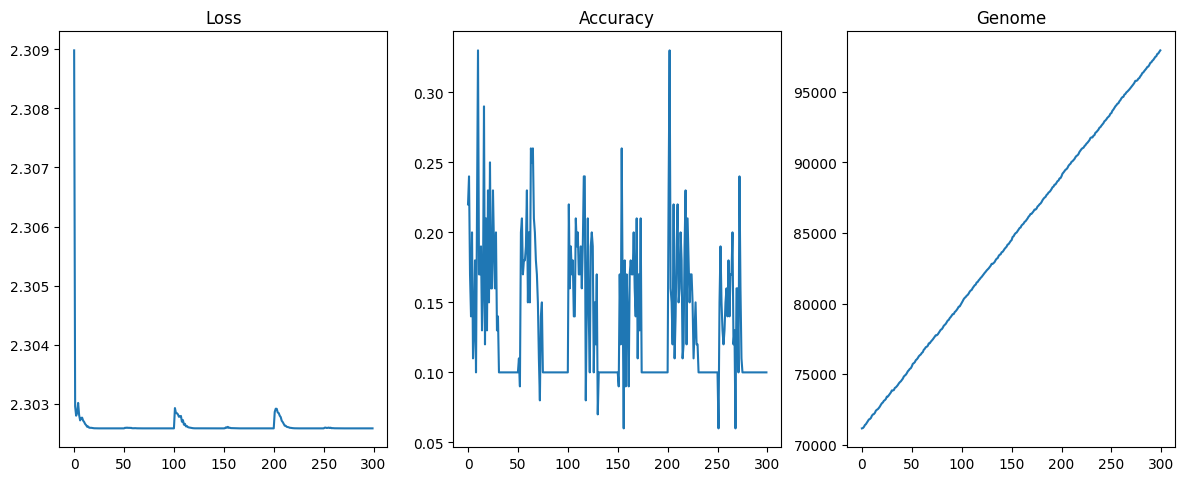

In [258]:
neat_losses = train(300)

In [46]:
MODEL.eval();

# Evaluate

In [47]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, guess=True, mean=True))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, guess=True, mean=True))*100

(89.75999999999999, 90.35)

In [48]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, keys=POPULATION.best_genome.key))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, keys=POPULATION.best_genome.key))*100

(61.0, 75.0)

In [49]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, guess=True, keys=POPULATION.best_genome.key))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, guess=True, keys=POPULATION.best_genome.key))*100

(90.0, 90.0)

In [50]:
def get_indices(images: Tensor, labels: Tensor, include: Union[int, list[int]] = None,
                faulty: int = False, correct: int = False, shuffle=True,
                keys: Union[int, list[int]] = None):
    if isinstance(include, (int, float)):
        include = [include]
    if keys and not isinstance(keys, (tuple, list)):
        keys = [keys]
    error_indices = []
    mapping = POPULATION.get_mapping()
    indices = list(range(len(images))) if not keys else [mapping[key] for key in keys]
    images, labels = images[indices], labels[indices]
    if faulty:
        if isinstance(faulty, bool):
            faulty = 64
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], faulty, False):
                pred = MODEL.evaluate(images[:, batch].to(MODEL.device), keys=keys)
                for index, errored in zip(batch, pred!=labels[:, batch].to(MODEL.device)):
                    if torch.any(errored):
                        error_indices.append(index)
        print(f"Found {len(error_indices)} record predictions with errors")
    valid_indices = []
    if correct:
        if isinstance(correct, bool):
            correct = 64
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], correct, False):
                pred = MODEL.evaluate(images[:, batch].to(MODEL.device), keys=keys)
                for index, correct in zip(batch, pred==labels[:, batch].to(MODEL.device)):
                    if torch.any(correct):
                        valid_indices.append(index)
        print(f"Found {len(valid_indices)} valid record predictions ")
    indices_filtered = []
    for g_labels in labels.cpu():
        for x, record in enumerate(g_labels.cpu().tolist()):
            record_needed = include is None or record in include
            spec_type = x in error_indices or x in valid_indices
            no_type = not correct and not faulty
            if record_needed and (spec_type or no_type):
                indices_filtered.append(x)
    indices_filtered = list(set(indices_filtered))
    if shuffle:
        random.shuffle(indices_filtered)
    if len(indices_filtered) > 0:
        return indices_filtered
    else:
        raise ValueError(f"No indices available")

In [51]:
test_records = 24
MODEL.eval();

In [52]:
train_indices = get_indices(train_inp, train_out, faulty=None, keys=POPULATION.best_genome.key)
len(train_indices)

100

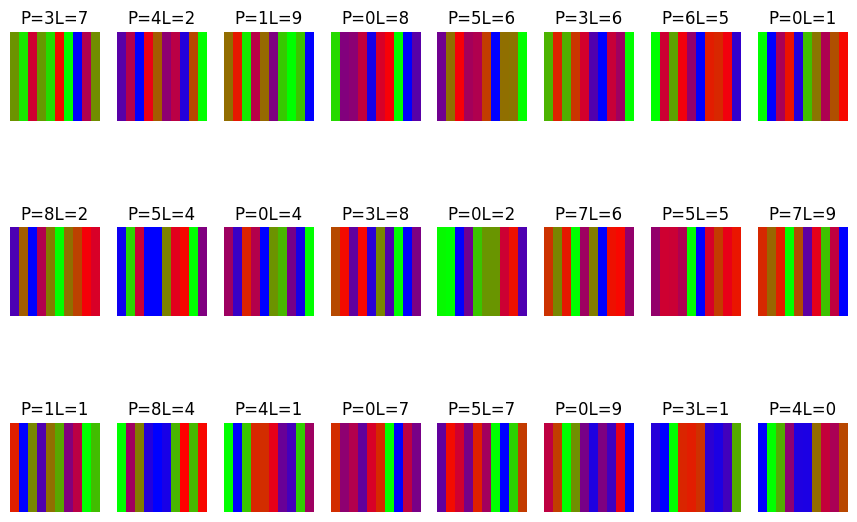

In [53]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [54]:
eval_indices = get_indices(eval_inp, eval_out, faulty=256, correct=False)
len(eval_indices)

Found 80 record predictions with errors


80

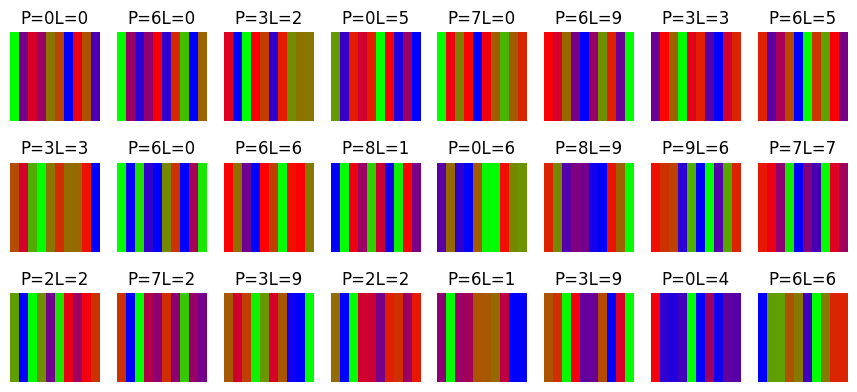

In [55]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

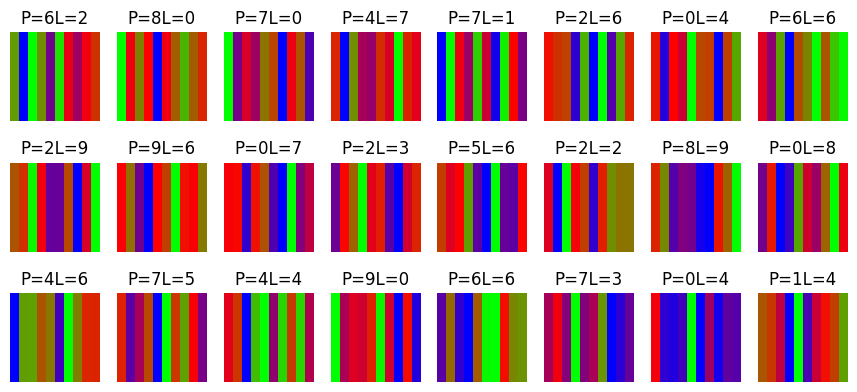

In [56]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

# PyTorch training

In [57]:
def train2(epochs: int, batch_size: int, key: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    MODEL.requires_grad_(True)
    # attention.causal_mask = False
    optimizer = torch.optim.AdamW(MODEL.parameters(), 1e-3)

    losses = []
    acc_train, acc_eval = [], []
    ts, ud, ut = clock.perf_counter(), 0, epochs

    # ------------------------------ Training Data ------------------------------ #
    index = POPULATION.get_mapping()[key]
    inputs, outputs = train_inp[index].unsqueeze(0).to(MODEL.device), train_out[index].unsqueeze(0).to(MODEL.device)
    print(inputs.shape, outputs.shape)

    best_loss = torch.inf
    best_epoch = -1
    save_state = MODEL.state_dict()
    batches = get_batches(inputs.shape[1], batch_size, True)
    for epoch in range(epochs):
        try:
            loss: Tensor = 0
            for batch in batches:
                # if epoch == 0:
                #     print(inputs.shape, outputs.shape)
                inp = inputs[:, batch].to(MODEL.device)
                out = outputs[0, batch].to(MODEL.device)
                predictions = MODEL(inp, keys=key).squeeze(0)
                # if epoch == 0:
                #     print(inp.shape, predictions.shape, out.shape)
                batch_loss = F.cross_entropy(predictions, out)
                batch_loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                loss += batch_loss
            loss /= len(batches)

            losses.append(loss.cpu().item())
            acc_train.append(get_accuracy(MODEL, train_inp, train_out, batch_size, True, keys=key))
            acc_eval.append(get_accuracy(MODEL, eval_inp, eval_out, batch_size, True, keys=key))

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = MODEL.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item():.4e} | "
                            f"best={best_loss.cpu().item():.4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break
    print(f"\nFinished training in {clock.perf_counter() - ts:.2f}s")

    MODEL.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.close()
        axes = plt.subplots(1, 2, figsize=(10.8, 5.4))[1]
        axes = axes.flatten()
        axes[0].plot(np.log10(losses))
        axes[0].set_title('Loss')
        axes[1].plot(acc_train, label='train')
        axes[1].plot(acc_eval, label='eval')
        axes[1].legend()
        axes[1].set_title('Accuracy')

    MODEL.requires_grad_(False)
    torch.cuda.empty_cache()
    return losses

torch.Size([1, 100, 1, 10]) torch.Size([1, 100])
training | loss=1.4035e-02 | best=1.4035e-02 | epoch=99: progress=100% eta=0sec
Finished training in 2.44s


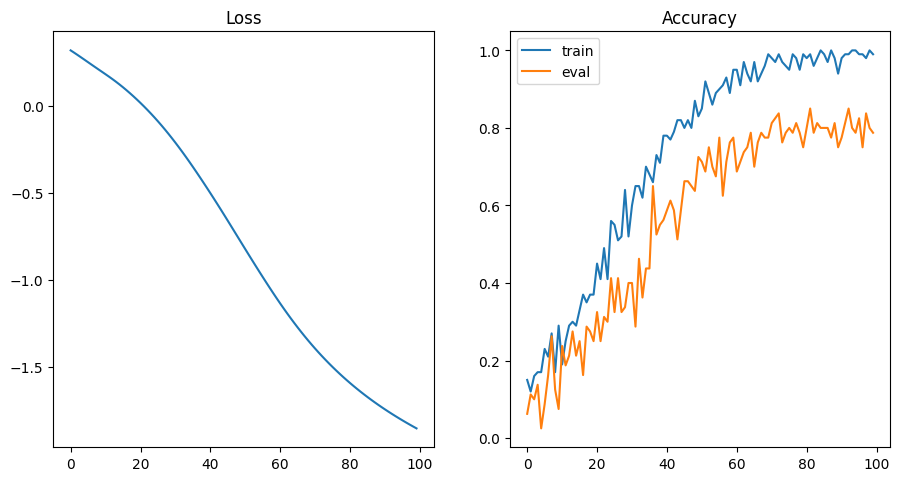

In [58]:
train_losses = train2(100, 256, POPULATION.best_genome.key, checkpoints=1)

In [59]:
list(POPULATION.genomes.keys())[:15], POPULATION.best_genome

([8836,
  7177,
  8931,
  7297,
  7294,
  6316,
  8927,
  7189,
  8949,
  6397,
  9010,
  9011,
  9012,
  9013,
  9014],
 <numba.experimental.jitclass.boxing.Genome at 0x218798fa260>)

In [60]:
extra_key = list(POPULATION.genomes.keys())[1]
extra_key

7177

torch.Size([1, 100, 1, 10]) torch.Size([1, 100])
training | loss=1.5199e-04 | best=1.5199e-04 | epoch=999: progress=100% eta=0sec
Finished training in 22.82s


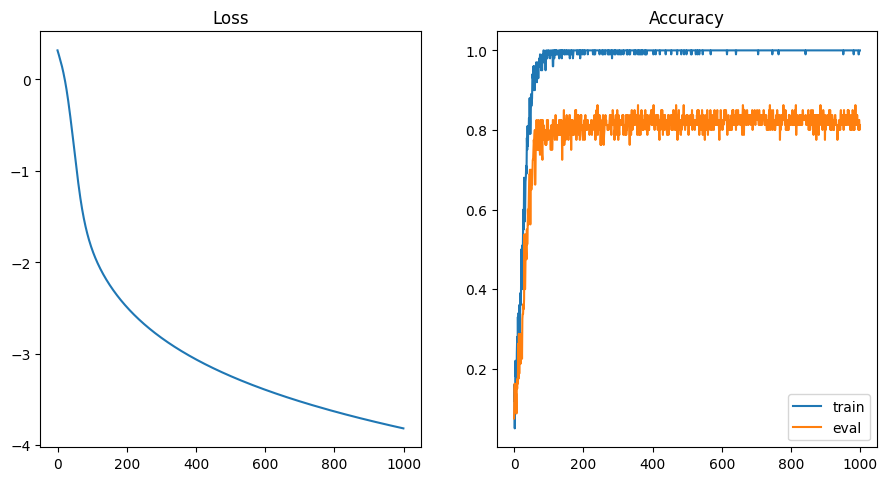

In [61]:
train2(1000, 256, extra_key, checkpoints=1);

In [62]:
extra_key2 = list(POPULATION.genomes.keys())[3]
extra_key2

7297

torch.Size([1, 100, 1, 10]) torch.Size([1, 100])
training | loss=1.5287e-03 | best=1.5287e-03 | epoch=299: progress=100% eta=0sec
Finished training in 6.84s


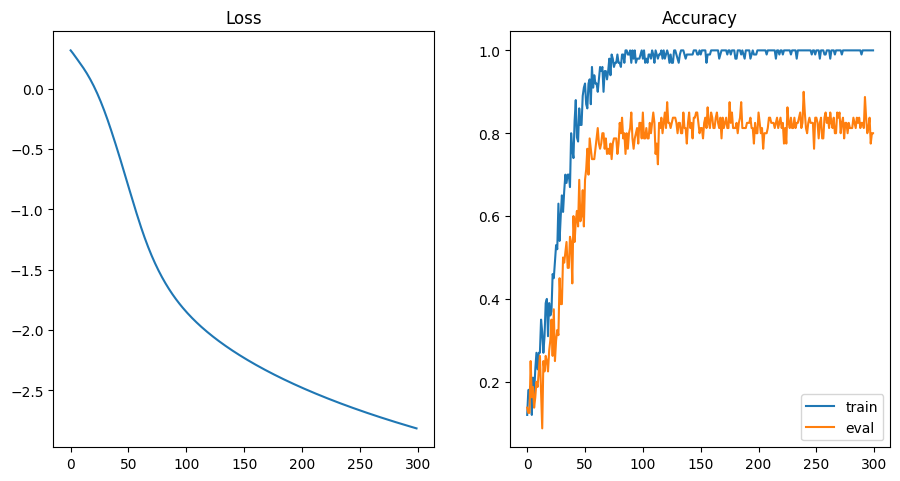

In [63]:
train2(300, 256, extra_key2, checkpoints=1);

In [64]:
keys_to_check = [*[g.key for g in POPULATION.best_genomes.values()], extra_key, extra_key2]
keys_to_check

[8836, 7177, 7297]

In [65]:
(1 - get_accuracy(MODEL, train_inp, train_out, 128, keys=POPULATION.best_genome.key)) * 100, \
(1 - get_accuracy(MODEL, eval_inp, eval_out, 128, keys=POPULATION.best_genome.key)) * 100

(0.0, 17.500000000000004)

In [66]:
(1 - get_accuracy(MODEL, train_inp, train_out, 128, guess=True, keys=POPULATION.best_genome.key)) * 100, \
(1 - get_accuracy(MODEL, eval_inp, eval_out, 128, guess=True, keys=POPULATION.best_genome.key)) * 100

(1.0000000000000009, 17.500000000000004)

In [67]:
train_indices = get_indices(train_inp, train_out, faulty=None, keys=POPULATION.best_genome.key)

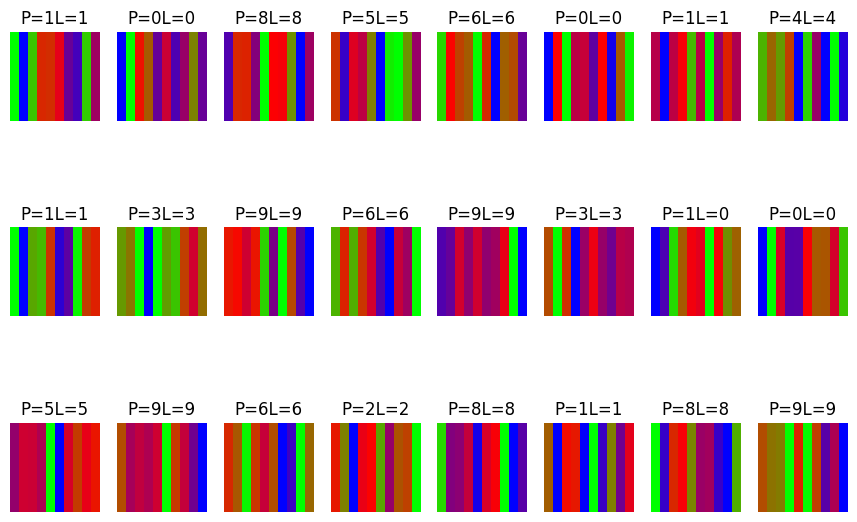

In [68]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [69]:
eval_indices = get_indices(eval_inp, eval_out, faulty=256, correct=False)
len(eval_indices)

Found 80 record predictions with errors


80

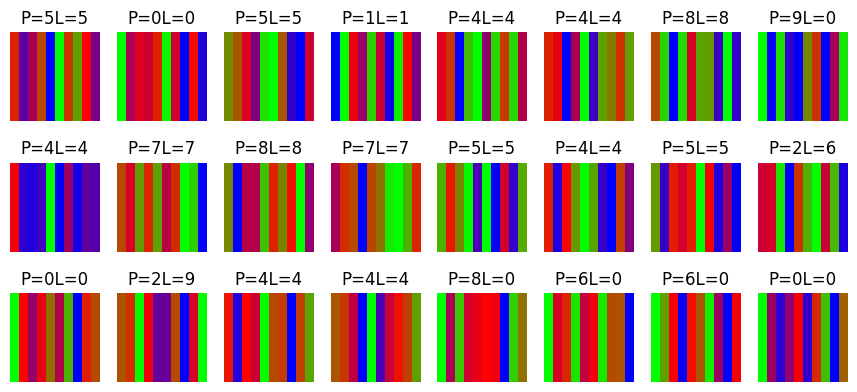

In [70]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

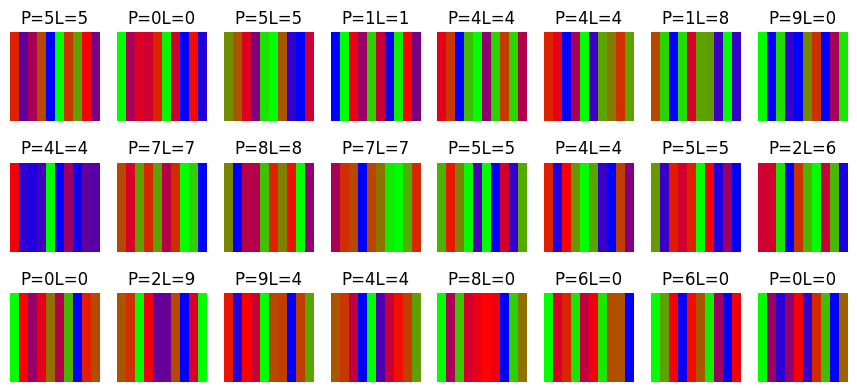

In [71]:
with torch.no_grad():
    # random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

# Evaluate on diffusion generated data

In [64]:
from diffusion_proj.models.simple import UNet
from diffusion_proj.diffusion import Diffusion

In [65]:
SEED = 100
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [66]:
diffusion = Diffusion(1e-3, 6e-1, timesteps=100)

NO_DISPLAY_IMAGES = 100
with torch.no_grad():
    test_image = train_inp[0]
    torch_image_batch = torch.stack([test_image] * NO_DISPLAY_IMAGES)
    test_timesteps = torch.linspace(0, diffusion.timesteps - 1, NO_DISPLAY_IMAGES).long()
    noisy_image_batch, _ = diffusion.forward(torch_image_batch, test_timesteps, DEVICE)
    show_batch(noisy_image_batch, columns=10, cmap=plt.cm.brg)

RuntimeError: Boolean value of Tensor with more than one value is ambiguous

In [ ]:
gen_model = UNet(
    1, 3, sequence_channels=[16 + 16 * n for n in range(5)], time_embeddings=diffusion.timesteps,
    label_embeddings=100, bias=False,
    layers=3, kernel_size_init=7, padding_mode='zeros', device=DEVICE, dtype=DTYPE
)

In [ ]:
IMG_SIZE = (64, 64)

In [ ]:
gen_model.load()

In [ ]:
# torch.gpu.empty_cache()
NUM_CLASSES = 10
NUM_DISPLAY_IMAGES = 10
for c in range(NUM_CLASSES):
    # imgs = torch.normal(MEAN, STD * 1., (NUM_DISPLAY_IMAGES, 1) + IMAGE_SHAPE).to(DEVICE)
    imgs = torch.randn(NUM_DISPLAY_IMAGES, 1, *IMG_SIZE).to(DEVICE)
    with torch.no_grad():
        fetch_ts = clock.perf_counter()
        labels = torch.full((NUM_DISPLAY_IMAGES,), c, device=DEVICE, dtype=torch.long)
        for i in reversed(range(diffusion.timesteps)):
            t = torch.full((1,), i, dtype=torch.long, device=DEVICE)
            # print(imgs.shape, labels.shape, t.shape)
            imgs = diffusion.backward(x=imgs, t=t, model=gen_model, labels=labels)
            eta(fetch_ts, diffusion.timesteps-i, diffusion.timesteps, f"Fetching {c+1}")
    print(imgs.shape)
    plt.close()
    show_batch(imgs, labels=torch.full((NUM_DISPLAY_IMAGES,), c), columns=NUM_DISPLAY_IMAGES, cmap='brg')
    plt.show()

plt.show()

In [ ]:
def create_data(records: int, batch_size: int, shuffle=True):
    torch.cuda.empty_cache()
    inputs, outputs = [], []
    ts, ud, ut = clock.perf_counter(), 0, math.ceil(records / batch_size) * 10 * diffusion.timesteps
    try:
        for number in range(10):
            inp, out = [], []
            for batch_idx in range(math.ceil(records / batch_size)):
                # Generate the image from noise
                with torch.no_grad():
                    batch_images = torch.randn(batch_size, 1, *IMG_SIZE).to(DEVICE, DTYPE)
                    batch_labels = torch.full((batch_size,), number, device=DEVICE, dtype=torch.long)
                    for t_step in reversed(range(diffusion.timesteps)):
                        batch_timestep = torch.full((1,), t_step, dtype=torch.long, device=DEVICE)
                        batch_images = diffusion.backward(x=batch_images, t=batch_timestep, model=gen_model, labels=batch_labels)
                        # Estimate time
                        ud += 1
                        eta(ts, ud, ut, f"Creating data from diffusion")
                # Append images
                inp.append(batch_images)
                out.append(batch_labels)
            # Concatenate batches and crop then append
            inp, out = torch.cat(inp)[:records], torch.cat(out)[:records]
            inputs.append(inp)
            outputs.append(out)
    except KeyboardInterrupt:
        torch.cuda.empty_cache()
        return None
    # Concat all numbers
    inputs, outputs = torch.cat(inputs), torch.cat(outputs)
    # Shuffle if required
    if shuffle:
        indices = list(range(len(inputs)))
        random.shuffle(indices)
        inputs, outputs = inputs[indices], outputs[indices]
    print(f"\nCompleted data creation of {len(outputs)} records in {round(clock.perf_counter()-ts)}s")
    torch.cuda.empty_cache()
    return transforms.Resize(train_inp.shape[-2:])(inputs), outputs

def normalize_data(inputs: Tensor):
    maximum, minimum = torch.max(inputs), torch.min(inputs)
    return (inputs - minimum) / (maximum - minimum)

In [ ]:
# diff_inp, diff_out = create_data(6000, 1024, True)
# diff_inp = normalize_data(diff_inp)

In [ ]:
def save_data(dataset: tuple[Tensor, Tensor], file_no: int = None, name="data",
              dir='diffusion', sub_dir='training_data', save_path: str = None):
    save(dataset, file_no=file_no, filename=name, directory=dir, subdirectory=sub_dir, save_location=save_path)

def load_data(file_no: int = None, name="data",  dir='diffusion', sub_dir='training_data',
              save_path: str = None) -> Union[tuple[Tensor, Tensor], None]:
    dataset = load(file_no=file_no, filename=name, directory=dir, subdirectory=sub_dir, save_location=save_path)
    if dataset is not None:
        return dataset
    else:
        raise ValueError(f"No dataset found in storage location")

In [ ]:
# save_data((diff_inp, diff_out), file_no=None)

In [ ]:
diff_inp, diff_out = load_data(file_no=None)

In [ ]:
diff_inp.shape, diff_out.shape

In [ ]:
show_batch(diff_inp[:32], labels=diff_out[:32], columns=8, cmap=plt.cm.brg)

In [ ]:
with torch.no_grad():
    show_batch(diff_inp[:32], predictions=MODEL.evaluate(diff_inp[:32]),
               labels=diff_out[:32], columns=8, cmap=plt.cm.brg)

In [ ]:
(1-get_accuracy(MODEL, diff_inp, diff_out, 256))*100, (1-get_accuracy(MODEL, diff_inp, diff_out, 256, guess=True))*100

In [ ]:
diff_indices = get_indices(diff_inp, diff_out, faulty=256)[:40]

In [ ]:
with torch.no_grad():
    random.shuffle(diff_indices)
    diff_eval_indices = diff_indices[:40]
    show_batch(diff_inp[diff_eval_indices], predictions=MODEL.evaluate(diff_inp[diff_eval_indices]),
               labels=diff_out[diff_eval_indices], columns=8, cmap=plt.cm.winter)

In [ ]:
with torch.no_grad():
    show_batch(diff_inp[diff_eval_indices], predictions=MODEL.guess(diff_inp[diff_eval_indices]),
               labels=diff_out[diff_eval_indices], columns=8, cmap=plt.cm.winter)

In [ ]:
train(MODEL, OPTIMIZER, 50, 128, acc_step=5, clip=0.5, scheduler=None, save_best=False,
      # train_dataset=(torch.cat([diff_inp, train_inp]), torch.cat([diff_out, train_out])),
      train_dataset=(diff_inp, diff_out),
      rot=10,
      )

In [ ]:
(1-get_accuracy(MODEL, diff_inp, diff_out, 128))*100, (1-get_accuracy(MODEL, diff_inp, diff_out, 128, guess=True))*100